# ======================================================================
# MODULE 5: DCT-QIM Extraction (Receiver Side)
# ======================================================================
#
# **Project:** QVSC — Quantum-assisted Video Steganographic Communication
#
# **Author:** Hasibul Hasan (Roll: 2003127, CSE, RUET)
#
# **Purpose:** Recover the hidden, FEC-protected ciphertext bits from the
# compressed stego video. This is the inverse of Module 4: the receiver
# decodes the H.264 video and reads the QIM-modulated bits from the
# Y-channel (luminance) DCT coefficients, using the sender's ROI masks
# for exact block alignment.
#
# **The system is NON-BLIND (important design point):**
# Extraction uses the sender's ROI masks (`roi_masks.npy`), transmitted as
# side-information alongside the metadata. We do NOT regenerate the masks
# at the receiver for extraction. Receiver-side regeneration was measured
# at only ~97% block agreement (see the diagnostic in Section 8), and
# because bits are packed sequentially into ROI blocks, even a single
# mismatched block desynchronizes the entire bitstream and produces ~50%
# BER. Sequential QIM embedding requires EXACT mask alignment, which only
# the transmitted masks can guarantee. (Recovering true blind extraction
# would need a desynchronization-resistant scheme — listed as future work.)
#
# **Channel / coefficient (must match Module 4):**
#   - Embed/extract channel : Y (luminance) — survives H.264 4:2:0
#     chroma subsampling, unlike Cr.
#   - DCT coefficient        : (2, 2), low-frequency — survives quantization.
#   - QIM step Δ             : 50.
#
# **Where FEC fits:** the bits recovered here still carry a small residual
# error rate from lossy compression (~0.2% at QP 23). They are NOT the raw
# ciphertext — they are the Reed-Solomon FEC payload. Module 6 FEC-decodes
# them (correcting the residual) before ChaCha20-Poly1305 decryption.
#
# **Input:**
# - `stego_compressed.mp4` (or `stego_with_audio.mp4`) — stego video (M4)
# - `embedding_metadata.npy` — params & per-frame bit counts (M4)
# - `roi_masks.npy`          — sender's ROI masks (M3), used for alignment
#
# **Output:**
# - `extracted_ciphertext.bin` — recovered FEC payload, feeds Module 6
# - `extraction_report.npy`    — BER, mask-drift diagnostic, per-frame metrics
#
# **Algorithm:**
# ```
# 1. Load embedding metadata (Δ, coeff position, payload size, bits-per-frame)
# 2. Open compressed stego video; decode all frames -> BGR
# 3. Load the sender's ROI masks (roi_masks.npy)
# 4. For each frame (using the sender's mask for that frame):
#    a. Convert BGR -> YCrCb, take the Y channel
#    b. For each ROI block (raster order, until the frame's bit budget):
#       i.   Apply 2D DCT
#       ii.  Read coefficient at position (2, 2)
#       iii. QIM inverse: b = 1 if (c - Δ·round(c/Δ)) > 0 else 0
# 5. Concatenate bits -> bytes -> extracted_ciphertext.bin (the FEC payload)
# 6. (Diagnostic) regenerate masks to measure drift; compute raw BER
# ```
#
# **Key Equation:**
#   QIM extract:  b = 1 if (c - Δ·round(c/Δ)) > 0 else 0
#
# **Compatibility note:** REUSES Module 4's DCT/QIM functions and Module 3's
# detect_roi(). All parameters load from `embedding_metadata.npy`, so any
# change in Module 4's config propagates here automatically.
#
# ======================================================================

## Section 1: Library Imports

In [1]:
import cv2
import numpy as np
from scipy.fft import dctn, idctn
import matplotlib.pyplot as plt
import os

print("All libraries imported successfully.")

All libraries imported successfully.


## Section 2: Configuration and Parameters

The receiver loads ALL embedding parameters from `embedding_metadata.npy`
which Module 4 saved at the end of its run. This guarantees parameter
consistency: if even one value (Δ, coefficient position, block size)
differs between embedding and extraction, every extracted bit will be
random noise.

The only inputs the receiver explicitly configures are:
- The path to the received compressed stego video
- The path to the metadata file
- The path to write the recovered ciphertext

In [2]:
# ── File paths (inputs from Module 4) ────────────────────────────────
STEGO_VIDEO_PATH    = 'stego_compressed.mp4'      # Received stego video
EMBED_META_FILE     = 'embedding_metadata.npy'    # Embedding metadata from M4
ROI_MASKS_FILE      = 'roi_masks.npy'             # Sender's ROI masks (from M3) — used for extraction

# ── Output paths ──────────────────────────────────────────────────────
EXTRACTED_CIPHERTEXT = 'extracted_ciphertext.bin' # Feeds into Module 6
EXTRACTION_REPORT    = 'extraction_report.npy'    # Diagnostic statistics

# ── Optional: original ciphertext for BER measurement ────────────────
# In a real deployment the receiver does NOT have this file. It is
# loaded here ONLY for thesis-experiment BER measurement.
ORIGINAL_CIPHERTEXT  = 'fec_payload.bin'          # FEC payload that Module 4 embedded
COMPUTE_BER          = True                       # Set False in production

# ── ROI detection parameters (must match Module 3 EXACTLY) ───────────
# These are duplicated here for clarity, but the values must match
# whatever Module 3 used at the sender. If you change M3, change here.
ROI_BLOCK_SIZE        = 8
ROI_CANNY_LOW         = 50
ROI_CANNY_HIGH        = 150
ROI_BLUR_SIGMA        = 1.0
ROI_DILATE_ITERATIONS = 2
ROI_EDGE_THRESHOLD    = 0.30

print("="*70)
print("  MODULE 5 CONFIGURATION (Receiver Side)")
print("="*70)
print(f"  Stego video (input):     {STEGO_VIDEO_PATH}")
print(f"  Metadata file:           {EMBED_META_FILE}")
print(f"  Extracted ciphertext:    {EXTRACTED_CIPHERTEXT}")
print(f"  Compute BER diagnostic:  {COMPUTE_BER}")
print("="*70)

  MODULE 5 CONFIGURATION (Receiver Side)
  Stego video (input):     stego_compressed.mp4
  Metadata file:           embedding_metadata.npy
  Extracted ciphertext:    extracted_ciphertext.bin
  Compute BER diagnostic:  True


## Section 3: Load Embedding Metadata from Module 4

Module 4 saved a dictionary of embedding parameters at the end of its
run. We load it here and unpack the values we need for extraction.

The critical parameters that must match the sender are:
- `block_size`     — DCT block size (8)
- `coeff_pos`      — Low-frequency coefficient position (2, 2)
- `qim_delta`      — QIM quantization step Δ (50)
- `payload_bits`   — Total number of bits to recover
- `bits_per_frame` — How many bits were embedded in each frame

In [3]:
# ── Load metadata ─────────────────────────────────────────────────────
if not os.path.exists(EMBED_META_FILE):
    raise FileNotFoundError(
        f"Metadata file '{EMBED_META_FILE}' not found.\n"
        f"Module 4 must be run first to generate this file."
    )

embedding_meta = np.load(EMBED_META_FILE, allow_pickle=True).item()

# ── Unpack the parameters needed for extraction ──────────────────────
BLOCK_SIZE     = embedding_meta['block_size']
COEFF_POS      = embedding_meta['coeff_pos']
QIM_DELTA      = embedding_meta['qim_delta']
PAYLOAD_BITS   = embedding_meta['payload_bits']
PAYLOAD_BYTES  = embedding_meta['payload_bytes']
BITS_PER_FRAME = embedding_meta['bits_per_frame']
TOTAL_FRAMES   = embedding_meta['total_frames']
FRAME_WIDTH    = embedding_meta['frame_width']
FRAME_HEIGHT   = embedding_meta['frame_height']

# ── Display loaded parameters ─────────────────────────────────────────
print("="*70)
print("  EMBEDDING METADATA (loaded from Module 4)")
print("="*70)
print(f"  Block size:           {BLOCK_SIZE}×{BLOCK_SIZE}")
print(f"  DCT coeff position:   {COEFF_POS}")
print(f"  QIM Δ (delta):        {QIM_DELTA}")
print(f"  Payload (bits):       {PAYLOAD_BITS}")
print(f"  Payload (bytes):      {PAYLOAD_BYTES}")
print(f"  Total frames:         {TOTAL_FRAMES}")
print(f"  Frame resolution:     {FRAME_WIDTH}×{FRAME_HEIGHT}")
print(f"  Modified frames:      {embedding_meta.get('modified_frames', 'N/A')}")
print(f"  Sender-side PSNR:     {embedding_meta.get('avg_psnr', 0):.2f} dB")
print(f"  Sender-side SSIM:     {embedding_meta.get('avg_ssim', 0):.4f}")
print("="*70)

  EMBEDDING METADATA (loaded from Module 4)
  Block size:           8×8
  DCT coeff position:   (2, 2)
  QIM Δ (delta):        50
  Payload (bits):       681360
  Payload (bytes):      85170
  Total frames:         425
  Frame resolution:     1920×1080
  Modified frames:      167
  Sender-side PSNR:     49.20 dB
  Sender-side SSIM:     0.9974


## Section 4: ROI Detection — Receiver Side

This is the same `detect_roi()` function from Module 3, copied here so
this notebook is self-contained. **The function must be byte-identical
to Module 3's version** — both Alice (sender) and Bob (receiver) call
this exact code, otherwise the masks will diverge and extraction will
fail.

The function takes a BGR frame and returns a **block-level binary mask**
of shape `(blocks_y, blocks_x)`, which is the format Module 4's
extraction loop expects.

In [4]:
def detect_roi_blocks(frame_bgr,
                      block_size=8,
                      canny_low=50,
                      canny_high=150,
                      blur_sigma=1.0,
                      dilate_iterations=2,
                      edge_threshold=0.30):
    """
    Receiver-side ROI detection. Returns a BLOCK-LEVEL mask of shape
    (blocks_y, blocks_x), matching the format Module 4 used.
    
    NOTE: Module 3's original detect_roi() returns a pixel-level mask.
    This wrapper produces the block-level format that the embedding
    and extraction loops actually use.
    
    Parameters are IDENTICAL to Module 3 — any change must be mirrored.
    
    Returns:
        block_mask : np.ndarray (blocks_y, blocks_x), uint8
            1 = ROI block (data was embedded here)
            0 = non-ROI block (skipped)
    """
    # Step 1: BGR → YCrCb, extract Y (luminance)
    ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)
    y_channel = ycrcb[:, :, 0]
    
    # Step 2: Gaussian blur (matches M3 exactly)
    y_blurred = cv2.GaussianBlur(y_channel, (5, 5), blur_sigma)
    
    # Step 3: Canny edge detection
    edges = cv2.Canny(y_blurred, canny_low, canny_high)
    
    # Step 4: Dilate to thicken edges
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges_dilated = cv2.dilate(edges, kernel, iterations=dilate_iterations)
    
    # Step 5: Compute block-level mask via edge density per 8×8 block
    height, width = edges_dilated.shape
    blocks_y = height // block_size
    blocks_x = width  // block_size
    
    block_mask = np.zeros((blocks_y, blocks_x), dtype=np.uint8)
    pixels_per_block = block_size * block_size
    
    for by in range(blocks_y):
        for bx in range(blocks_x):
            y0 = by * block_size
            x0 = bx * block_size
            block = edges_dilated[y0:y0+block_size, x0:x0+block_size]
            edge_density = np.count_nonzero(block) / pixels_per_block
            
            if edge_density > edge_threshold:
                block_mask[by, bx] = 1
    
    return block_mask


print("Receiver-side detect_roi_blocks() defined.")

Receiver-side detect_roi_blocks() defined.


## Section 5: DCT and QIM Functions

These are the same `apply_dct_2d()` and `qim_extract_bit()` functions
from Module 4. The QIM extraction logic is the inverse of QIM
embedding: it reads the remainder after dividing by Δ and decides
which lattice the coefficient belongs to.

**QIM extraction rule:**
$$b = \\begin{cases} 1 & \\text{if } (c - \\Delta \\cdot \\text{round}(c/\\Delta)) > 0 \\\\ 0 & \\text{otherwise} \\end{cases}$$

If H.264 compression has perturbed the coefficient by less than Δ/4,
the correct bit is recovered. Δ=50 (chosen in Module 4) gives a ±12.5
margin; any residual errors that slip through are corrected later by the
Reed-Solomon FEC layer in Module 6.

In [5]:
def apply_dct_2d(block):
    """
    Apply 2D Type-II DCT to an 8×8 block (orthonormal).
    Identical to Module 4's apply_dct_2d().
    """
    return dctn(block, type=2, norm='ortho')


def qim_extract_bit(coeff, delta):
    """
    Extract one bit from a (possibly noise-perturbed) DCT coefficient.
    
    Logic:
      quantized = Δ · round(c / Δ)
      remainder = c - quantized
      bit = 1 if remainder > 0 else 0
    
    This works because Module 4 embedded:
      bit=1 → c' = quantized + Δ/4   (positive remainder)
      bit=0 → c' = quantized - Δ/4   (negative remainder)
    
    H.264 compression noise of magnitude < Δ/4 cannot flip the sign
    of the remainder, so the bit survives.
    """
    quantized = delta * np.round(coeff / delta)
    remainder = coeff - quantized
    return 1 if remainder > 0 else 0


print("DCT and QIM extraction functions defined.")

DCT and QIM extraction functions defined.


## Section 6: Per-Frame Extraction Function

This function pulls bits out of a single BGR frame using the sender's
ROI mask for that frame (the system is non-blind). The iteration order
must match Module 4 exactly: raster scan top-left → bottom-right,
skipping non-ROI blocks, stopping when the frame's bit budget is exhausted.

In [6]:
def extract_from_frame(frame_bgr, block_mask, num_bits_to_extract,
                       block_size=8, coeff_pos=(2, 2), delta=50):
    """
    Extract hidden bits from a single frame using DCT-QIM in the Y channel.
    
    This is identical to Module 4's extract_from_frame() — duplicated
    here so Module 5 can run as a standalone receiver script.
    
    Parameters:
        frame_bgr           : np.ndarray (H, W, 3) — received BGR frame
        block_mask          : np.ndarray (blocks_y, blocks_x) — ROI mask
                              (the sender's mask, for exact alignment)
        num_bits_to_extract : int — how many bits this frame carries
        block_size          : int — DCT block size (must match M4)
        coeff_pos           : tuple — DCT coefficient position
        delta               : float — QIM quantization step Δ
    
    Returns:
        extracted_bits : list of int — bits 0/1 in embedding order
    """
    # Step 1: BGR → YCrCb → extract Y (luminance) channel as float64
    ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)
    cr_channel = ycrcb[:, :, 0].astype(np.float64)  # Y (luminance) — matches Module 4
    
    blocks_y, blocks_x = block_mask.shape
    extracted_bits = []
    u, v = coeff_pos
    
    # Step 2: Iterate over blocks in raster order (matches M4 embedding order)
    for by in range(blocks_y):
        for bx in range(blocks_x):
            if len(extracted_bits) >= num_bits_to_extract:
                break
            
            # Skip non-ROI blocks (these were skipped during embedding too)
            if block_mask[by, bx] == 0:
                continue
            
            # Step 3: Extract 8×8 block, apply DCT
            y0 = by * block_size
            x0 = bx * block_size
            block = cr_channel[y0:y0+block_size, x0:x0+block_size]
            dct_block = apply_dct_2d(block)
            
            # Step 4: QIM-decode the target coefficient
            coeff = dct_block[u, v]
            bit = qim_extract_bit(coeff, delta)
            extracted_bits.append(bit)
        
        if len(extracted_bits) >= num_bits_to_extract:
            break
    
    return extracted_bits


print("Per-frame extraction function defined.")

Per-frame extraction function defined.


## Section 7: Load the Received (Compressed) Stego Video

We load the H.264-compressed video that arrived over the public channel.
This is exactly what a real receiver would have — no access to the
original cover frames, no access to the sender's masks, no access to
the original ciphertext. Only the compressed video and the (publicly
shared) embedding parameters.

In [7]:
# ── Section 7-pre: Separate the audio from the received video ─────────
# The video that arrived over the channel carries the original audio track
# (the sender muxed it back in). Steganographic extraction needs only the
# VIDEO frames, so we split the container BEFORE extraction. The video
# stream is copied out byte-for-byte ("-c:v copy" -> payload untouched) into
# stego_compressed.mp4, which the next cell already loads. The audio is
# saved separately in case it is needed. No video re-encoding happens here,
# so the embedded coefficients survive exactly.
import subprocess   # Module 5's import cell doesn't include this

RECEIVED_VIDEO_PATH = 'stego_final.mp4'      # what actually arrived (has sound)
SEPARATED_AUDIO     = 'received_audio.aac'   # audio split off (optional)

def separate_audio(received_path, video_out_path, audio_out_path):
    """Split the received container into a video-only file (payload carrier,
       stream-copied) and an audio-only file (best effort)."""
    v = subprocess.run(
        ['ffmpeg', '-y', '-i', received_path, '-an', '-c:v', 'copy', video_out_path],
        capture_output=True, text=True, timeout=600)
    a = subprocess.run(
        ['ffmpeg', '-y', '-i', received_path, '-vn', '-acodec', 'copy', audio_out_path],
        capture_output=True, text=True, timeout=600)
    return v.returncode == 0, a.returncode == 0

if os.path.exists(RECEIVED_VIDEO_PATH):
    v_ok, a_ok = separate_audio(RECEIVED_VIDEO_PATH, STEGO_VIDEO_PATH, SEPARATED_AUDIO)
    print("="*70)
    print("  AUDIO SEPARATED FROM RECEIVED VIDEO")
    print("="*70)
    print(f"  Received (with sound):        {RECEIVED_VIDEO_PATH}")
    print(f"  Video-only (for extraction):  {STEGO_VIDEO_PATH}  {'✓' if v_ok else '✗'}")
    print(f"  Audio saved separately:       {SEPARATED_AUDIO}  {'✓' if a_ok else '(none)'}")
    print("="*70)
else:
    print(f"  '{RECEIVED_VIDEO_PATH}' not found — "
          f"using existing '{STEGO_VIDEO_PATH}' as-is.")

  AUDIO SEPARATED FROM RECEIVED VIDEO
  Received (with sound):        stego_final.mp4
  Video-only (for extraction):  stego_compressed.mp4  ✓
  Audio saved separately:       received_audio.aac  ✓


In [8]:
def extract_frames(video_path, max_frames=None):
    """
    Open a video and decode all frames into a list of BGR arrays.
    Same helper used in Module 3 and Module 4.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")
    
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    frames = []
    count  = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
        count += 1
        if max_frames and count >= max_frames:
            break
    cap.release()
    return frames, fps, width, height


# ── Load the stego video ──────────────────────────────────────────────
if not os.path.exists(STEGO_VIDEO_PATH):
    raise FileNotFoundError(
        f"Stego video '{STEGO_VIDEO_PATH}' not found.\n"
        f"Module 4 must be run first to generate this file."
    )

received_frames, fps, vid_w, vid_h = extract_frames(STEGO_VIDEO_PATH)

print("="*70)
print("  RECEIVED STEGO VIDEO")
print("="*70)
print(f"  Path:              {STEGO_VIDEO_PATH}")
print(f"  File size:         {os.path.getsize(STEGO_VIDEO_PATH)/1024:.1f} KB")
print(f"  Frames decoded:    {len(received_frames)}")
print(f"  Resolution:        {vid_w}×{vid_h}")
print(f"  FPS:               {fps}")
print("="*70)

# ── Sanity check: dimensions must match what M4 embedded with ─────────
if vid_w != FRAME_WIDTH or vid_h != FRAME_HEIGHT:
    print(f"  ⚠ Resolution mismatch — extraction may fail")
    print(f"    Expected: {FRAME_WIDTH}×{FRAME_HEIGHT}")
    print(f"    Got:      {vid_w}×{vid_h}")
else:
    print(f"  ✓ Resolution matches embedding metadata")

  RECEIVED STEGO VIDEO
  Path:              stego_compressed.mp4
  File size:         99175.7 KB
  Frames decoded:    424
  Resolution:        1920×1080
  FPS:               30.0
  ✓ Resolution matches embedding metadata


## Section 8: Mask-Drift Diagnostic (regenerate masks to MEASURE drift)

This section regenerates the ROI masks from the received frames — but
**only as a diagnostic**, not for extraction. Extraction (Section 9) uses
the sender's transmitted masks, because sequential QIM embedding needs
exact block alignment.

**What this diagnostic shows:**
H.264 is perceptually optimized and largely preserves edges, so the
regenerated Canny masks agree with the sender's by ~95–99% per frame.
That sounds high — but it is NOT enough for blind extraction: a single
disagreeing block shifts every subsequent bit in that frame, cascading
to ~50% BER. Measuring this drift is precisely the evidence that justifies
transmitting the masks (the non-blind design choice).

So read the agreement percentage below as "how close blind regeneration
*would* get" — and the answer is "close, but not exact enough," which is
the whole point.

In [9]:
# ── Regenerate ROI masks for every received frame ────────────────────
print("Regenerating ROI masks from received frames...")
print("  (This is what a real receiver would do — no shared mask data)")

regenerated_masks = []
for idx, frame in enumerate(received_frames):
    mask = detect_roi_blocks(
        frame,
        block_size       = ROI_BLOCK_SIZE,
        canny_low        = ROI_CANNY_LOW,
        canny_high       = ROI_CANNY_HIGH,
        blur_sigma       = ROI_BLUR_SIGMA,
        dilate_iterations= ROI_DILATE_ITERATIONS,
        edge_threshold   = ROI_EDGE_THRESHOLD
    )
    regenerated_masks.append(mask)
    
    if (idx + 1) % 10 == 0 or idx == len(received_frames) - 1:
        print(f"  Frame {idx+1}/{len(received_frames)} — "
              f"ROI blocks: {int(np.sum(mask))}")

regenerated_masks = np.array(regenerated_masks)

print(f"\nAll masks regenerated.")
print(f"  Shape:               {regenerated_masks.shape}")
print(f"  Total ROI blocks:    {int(np.sum(regenerated_masks))}")

Regenerating ROI masks from received frames...
  (This is what a real receiver would do — no shared mask data)
  Frame 10/424 — ROI blocks: 293
  Frame 20/424 — ROI blocks: 272
  Frame 30/424 — ROI blocks: 291
  Frame 40/424 — ROI blocks: 294
  Frame 50/424 — ROI blocks: 302
  Frame 60/424 — ROI blocks: 345
  Frame 70/424 — ROI blocks: 355
  Frame 80/424 — ROI blocks: 401
  Frame 90/424 — ROI blocks: 498
  Frame 100/424 — ROI blocks: 474
  Frame 110/424 — ROI blocks: 497
  Frame 120/424 — ROI blocks: 11807
  Frame 130/424 — ROI blocks: 11602
  Frame 140/424 — ROI blocks: 11546
  Frame 150/424 — ROI blocks: 11364
  Frame 160/424 — ROI blocks: 11200
  Frame 170/424 — ROI blocks: 11054
  Frame 180/424 — ROI blocks: 10894
  Frame 190/424 — ROI blocks: 10624
  Frame 200/424 — ROI blocks: 10400
  Frame 210/424 — ROI blocks: 10153
  Frame 220/424 — ROI blocks: 18823
  Frame 230/424 — ROI blocks: 18555
  Frame 240/424 — ROI blocks: 18566
  Frame 250/424 — ROI blocks: 18357
  Frame 260/424 — RO

In [10]:
# ── DIAGNOSTIC: Compare regenerated masks vs. sender's masks ──────────
# In a real deployment this comparison cannot be done — the receiver
# has no access to the sender's masks. We do it here for the thesis
# experiment to quantify mask drift caused by H.264 compression.

ROI_MASKS_FILE_M3 = 'roi_masks.npy'  # Sender's original masks (from M3)

if os.path.exists(ROI_MASKS_FILE_M3):
    sender_masks = np.load(ROI_MASKS_FILE_M3)
    
    # Trim to the frames we actually decoded (in case of frame count mismatch)
    n_compare = min(len(sender_masks), len(regenerated_masks))
    
    sender_trim    = sender_masks[:n_compare]
    receiver_trim  = regenerated_masks[:n_compare]
    
    # Per-frame agreement
    matches_per_frame = np.sum(sender_trim == receiver_trim, axis=(1, 2))
    blocks_per_frame  = sender_trim.shape[1] * sender_trim.shape[2]
    agreement_pct     = matches_per_frame / blocks_per_frame * 100
    
    overall_agreement = np.sum(sender_trim == receiver_trim) / sender_trim.size * 100
    
    print("="*70)
    print("  MASK AGREEMENT DIAGNOSTIC (sender vs. receiver)")
    print("="*70)
    print(f"  Frames compared:        {n_compare}")
    print(f"  Mean per-frame:         {np.mean(agreement_pct):.2f}%")
    print(f"  Min  per-frame:         {np.min(agreement_pct):.2f}%")
    print(f"  Max  per-frame:         {np.max(agreement_pct):.2f}%")
    print(f"  Overall:                {overall_agreement:.2f}%")
    print("="*70)
    
    # NOTE: this agreement is INFORMATIONAL ONLY. Extraction (below) uses the
    # sender's masks, because sequential QIM embedding needs EXACT mask
    # alignment — even 99% agreement desynchronizes the bitstream. This
    # diagnostic quantifies the drift that motivates transmitting the masks.
    print(f"  Mask drift under H.264: {100 - overall_agreement:.2f}% of blocks differ.")
    print(f"  (Extraction uses the sender's masks, so this does not affect BER.)")
    print("="*70)

    # ── Persist the diagnostic data for the thesis / presentation ──
    mask_agreement_data = {
        'per_frame_pct':   agreement_pct.tolist(),
        'overall_pct':     float(overall_agreement),
        'mean_pct':        float(np.mean(agreement_pct)),
        'min_pct':         float(np.min(agreement_pct)),
        'max_pct':         float(np.max(agreement_pct)),
        'frames_compared': int(n_compare),
        'drift_pct':       float(100 - overall_agreement),
    }
    np.save('mask_agreement.npy', mask_agreement_data)
    print(f"  Saved per-frame agreement data -> 'mask_agreement.npy'")
else:
    print("  (Sender's masks not available — skipping mask agreement diagnostic)")
    print("  This is the normal scenario in production deployment.")

  MASK AGREEMENT DIAGNOSTIC (sender vs. receiver)
  Frames compared:        424
  Mean per-frame:         97.36%
  Min  per-frame:         93.67%
  Max  per-frame:         99.84%
  Overall:                97.36%
  Mask drift under H.264: 2.64% of blocks differ.
  (Extraction uses the sender's masks, so this does not affect BER.)
  Saved per-frame agreement data -> 'mask_agreement.npy'


## Section 9: Extract Bits from All Frames

Now we run the full extraction loop. For each frame we:
1. Use the **sender's** ROI mask for that frame (the system is non-blind —
   this guarantees exact block alignment with embedding).
2. Pull `bits_per_frame[i]` bits in raster-scan order.
3. Concatenate into a single bitstream.

The total number of extracted bits should equal `PAYLOAD_BITS` from the
metadata. The recovered bytes are the FEC payload (with a small residual
error rate), which Module 6 will FEC-decode and then decrypt.

In [11]:
# ── Extract bits from each frame using the receiver's regenerated mask ─
print("Extracting payload bits from received stego video...")

# IMPORTANT: extraction uses the SENDER'S masks (roi_masks.npy), not the
# regenerated ones. Bits are packed sequentially into ROI blocks, so the
# masks must match EXACTLY — receiver regeneration only agrees ~90-99%,
# and a single mismatched block desynchronizes the whole stream (~50% BER).
# The regenerated masks above are kept only as a mask-drift diagnostic.
extraction_masks = np.load(ROI_MASKS_FILE)

all_extracted_bits = []
extraction_log     = []
bits_remaining     = PAYLOAD_BITS

for idx, frame in enumerate(received_frames):
    if bits_remaining <= 0:
        break
    
    # How many bits should this frame carry? (from M4 metadata)
    if idx >= len(BITS_PER_FRAME):
        break
    bits_in_frame = BITS_PER_FRAME[idx]
    
    if bits_in_frame == 0:
        extraction_log.append({'frame': idx, 'bits': 0, 'status': 'skipped'})
        continue
    
    # Use the SENDER'S mask (shared side-information) for exact alignment
    mask = extraction_masks[idx]
    
    extracted = extract_from_frame(
        frame, mask, bits_in_frame,
        block_size=BLOCK_SIZE, coeff_pos=COEFF_POS, delta=QIM_DELTA
    )
    
    all_extracted_bits.extend(extracted)
    bits_remaining -= len(extracted)
    extraction_log.append({
        'frame':  idx,
        'bits':   len(extracted),
        'status': 'ok' if len(extracted) == bits_in_frame else 'short'
    })

extracted_bits_array = np.array(all_extracted_bits, dtype=np.uint8)

print(f"\n  Total bits extracted:  {len(extracted_bits_array)}")
print(f"  Expected:              {PAYLOAD_BITS}")

if len(extracted_bits_array) < PAYLOAD_BITS:
    deficit = PAYLOAD_BITS - len(extracted_bits_array)
    print(f"  ⚠ Short by {deficit} bits — likely cause: ROI mask drift")
    print(f"    Padding with zeros so byte conversion still works.")
    extracted_bits_array = np.pad(
        extracted_bits_array,
        (0, deficit),
        mode='constant',
        constant_values=0
    )
elif len(extracted_bits_array) > PAYLOAD_BITS:
    print(f"  ⚠ {len(extracted_bits_array) - PAYLOAD_BITS} extra bits — truncating.")
    extracted_bits_array = extracted_bits_array[:PAYLOAD_BITS]
else:
    print(f"  ✓ Exact match")

Extracting payload bits from received stego video...

  Total bits extracted:  681360
  Expected:              681360
  ✓ Exact match


## Section 10: Bit Error Rate (BER) Diagnostic

The raw BER measures how many bits flipped between Alice's embedded FEC
payload and Bob's recovered bits, after the lossy operations:
- DCT → IDCT round-trip and pixel clipping to [0, 255]
- H.264 lossy compression at constant QP
- (extraction itself is exact, since it uses the sender's masks)

**Interpretation:** a small raw BER here is EXPECTED and fine — it does
not need to be zero. The Reed-Solomon FEC layer in Module 6 corrects the
residual (its budget is ~6% byte errors with interleaving), delivering a
byte-exact ciphertext to ChaCha20-Poly1305. The true success criterion is
Module 6's decryption PASS, not a zero here. BER only becomes a problem if
it climbs past the FEC budget (which happens at high QP).

In [12]:
# ── Compare against original ciphertext bits (if available) ──────────
ber                = None
errors             = None
original_bits      = None
match_with_original = None

if COMPUTE_BER and os.path.exists(ORIGINAL_CIPHERTEXT):
    with open(ORIGINAL_CIPHERTEXT, 'rb') as f:
        original_blob = f.read()
    
    # Convert original ciphertext bytes to bits (MSB-first, matches M4)
    original_bits = []
    for byte in original_blob:
        for bit_pos in range(7, -1, -1):
            original_bits.append((byte >> bit_pos) & 1)
    original_bits = np.array(original_bits, dtype=np.uint8)
    
    # Compute BER on the overlapping region
    n_compare = min(len(original_bits), len(extracted_bits_array))
    errors    = int(np.sum(extracted_bits_array[:n_compare] != original_bits[:n_compare]))
    ber       = errors / n_compare * 100 if n_compare > 0 else 0.0
    
    print("="*70)
    print("  BIT ERROR RATE (BER) — Compressed-Channel Extraction")
    print("="*70)
    print(f"  Bits compared:       {n_compare}")
    print(f"  Bit errors:          {errors}")
    print(f"  BER:                 {ber:.4f}%")
    
    if ber == 0.0:
        print(f"  ✓ ZERO raw BER — payload survived QP H.264 compression exactly")
        print(f"    Module 6 will FEC-decode and decrypt successfully.")
    elif ber < 5.0:
        print(f"  ✓ Low raw BER ({ber:.4f}%) — within the Reed-Solomon FEC budget")
        print(f"    Module 6 corrects this to a byte-exact ciphertext; decryption PASS.")
    else:
        print(f"  ✗ High BER ({ber:.4f}%) — likely beyond the FEC correction budget")
        print(f"    → Lower QP in Module 4, or raise RS_PARITY in fec_module.py")
    print("="*70)
else:
    print("  Original ciphertext not available — skipping BER measurement.")
    print("  In production, BER cannot be computed (receiver has no reference).")
    print("  Module 6's Poly1305 tag verification serves as the success criterion.")

  BIT ERROR RATE (BER) — Compressed-Channel Extraction
  Bits compared:       681360
  Bit errors:          1217
  BER:                 0.1786%
  ✓ Low raw BER (0.1786%) — within the Reed-Solomon FEC budget
    Module 6 corrects this to a byte-exact ciphertext; decryption PASS.


## Section 11: Convert Extracted Bits to Bytes and Save

Module 4 packed bytes into bits MSB-first (most significant bit at
lowest index). We reverse that here exactly: every 8 consecutive bits
become one byte, with bit 0 at MSB position.

The output file `extracted_ciphertext.bin` has the same structure as
Module 2's `ciphertext.bin`:

```
[ Nonce (12B) ][ Ciphertext (variable) ][ Poly1305 tag (16B) ]
```

This file feeds directly into **Module 6** (ChaCha20-Poly1305
decryption + tag verification).

In [13]:
def bits_to_bytes(bits):
    """
    Pack a bit array (MSB-first) into bytes.
    
    Inverse of the bytes-to-bits conversion in Module 4 Section 3a.
    
    If the bit count is not a multiple of 8, pad with zeros at the end
    (this should never happen — Module 4 always embeds full bytes).
    """
    bits = np.asarray(bits, dtype=np.uint8)
    
    # Pad to a multiple of 8 if needed
    pad = (-len(bits)) % 8
    if pad:
        bits = np.concatenate([bits, np.zeros(pad, dtype=np.uint8)])
    
    # Reshape into rows of 8 bits, then collapse each row into a byte
    bits_2d = bits.reshape(-1, 8)
    weights = np.array([128, 64, 32, 16, 8, 4, 2, 1], dtype=np.uint8)
    byte_array = np.sum(bits_2d * weights, axis=1).astype(np.uint8)
    
    return bytes(byte_array)


# ── Convert and save ──────────────────────────────────────────────────
extracted_bytes = bits_to_bytes(extracted_bits_array[:PAYLOAD_BITS])

# Sanity check: byte count must match what Module 4 embedded
expected_bytes = PAYLOAD_BYTES
got_bytes      = len(extracted_bytes)

if got_bytes != expected_bytes:
    print(f"  ⚠ Byte count mismatch — expected {expected_bytes}, got {got_bytes}")
    # Truncate or pad to expected size
    if got_bytes > expected_bytes:
        extracted_bytes = extracted_bytes[:expected_bytes]
    else:
        extracted_bytes = extracted_bytes + b'\x00' * (expected_bytes - got_bytes)

with open(EXTRACTED_CIPHERTEXT, 'wb') as f:
    f.write(extracted_bytes)

print("="*70)
print("  EXTRACTED CIPHERTEXT SAVED")
print("="*70)
print(f"  File:           {EXTRACTED_CIPHERTEXT}")
print(f"  Size:           {len(extracted_bytes)} bytes")
print(f"  Structure:      [12B nonce][{len(extracted_bytes)-28}B ct][16B tag]")
print()
print(f"  First 16 bytes (hex): {extracted_bytes[:16].hex()}")
print(f"  Last  16 bytes (hex): {extracted_bytes[-16:].hex()}")
print("="*70)

  EXTRACTED CIPHERTEXT SAVED
  File:           extracted_ciphertext.bin
  Size:           85170 bytes
  Structure:      [12B nonce][85142B ct][16B tag]

  First 16 bytes (hex): 045476f285dd661516a2b45633e99e2a
  Last  16 bytes (hex): 8787dacf036346722ceb3d7e1717c7de


In [14]:
# ── DIAGNOSTIC: Byte-level diff vs. original (if available) ───────────
if os.path.exists(ORIGINAL_CIPHERTEXT):
    with open(ORIGINAL_CIPHERTEXT, 'rb') as f:
        original_bytes = f.read()
    
    # Pad / trim for comparison
    n_compare      = min(len(original_bytes), len(extracted_bytes))
    byte_errors    = sum(
        1 for i in range(n_compare)
        if original_bytes[i] != extracted_bytes[i]
    )
    perfect_match  = (extracted_bytes == original_bytes)
    
    print("="*70)
    print("  BYTE-LEVEL COMPARISON (embedded FEC payload vs. recovered FEC payload)")
    print("="*70)
    print(f"  Bytes compared:    {n_compare}")
    print(f"  Byte errors:       {byte_errors}")
    print(f"  Byte error rate:   {byte_errors/n_compare*100:.4f}%")
    print(f"  Perfect match:     {'YES ✓' if perfect_match else 'NO ✗'}")
    
    if perfect_match:
        print(f"\n  ✓ Recovered FEC payload is BYTE-IDENTICAL to the embedded one.")
        print(f"    (Even the residual errors were zero this run.)")
    else:
        print(f"\n  Residual byte differences are EXPECTED from lossy compression.")
        print(f"    Reed-Solomon FEC in Module 6 corrects these to a byte-exact")
        print(f"    ciphertext before ChaCha20-Poly1305 decryption.")
    print("="*70)
else:
    print("  (Original ciphertext not available — Module 6 will be the verifier)")

  BYTE-LEVEL COMPARISON (embedded FEC payload vs. recovered FEC payload)
  Bytes compared:    85170
  Byte errors:       1127
  Byte error rate:   1.3232%
  Perfect match:     NO ✗

  Residual byte differences are EXPECTED from lossy compression.
    Reed-Solomon FEC in Module 6 corrects these to a byte-exact
    ciphertext before ChaCha20-Poly1305 decryption.


## Section 12: Visualization — Mask Agreement and Per-Frame Stats

We render two visual diagnostics:
1. **Mask agreement heatmap** — shows which blocks the sender and
   receiver disagree on (in production this view doesn't exist, but
   it's invaluable for thesis figures explaining why H.264 doesn't
   break the system).
2. **Per-frame bit count** — verifies that each frame contributed the
   number of bits Module 4 said it did.

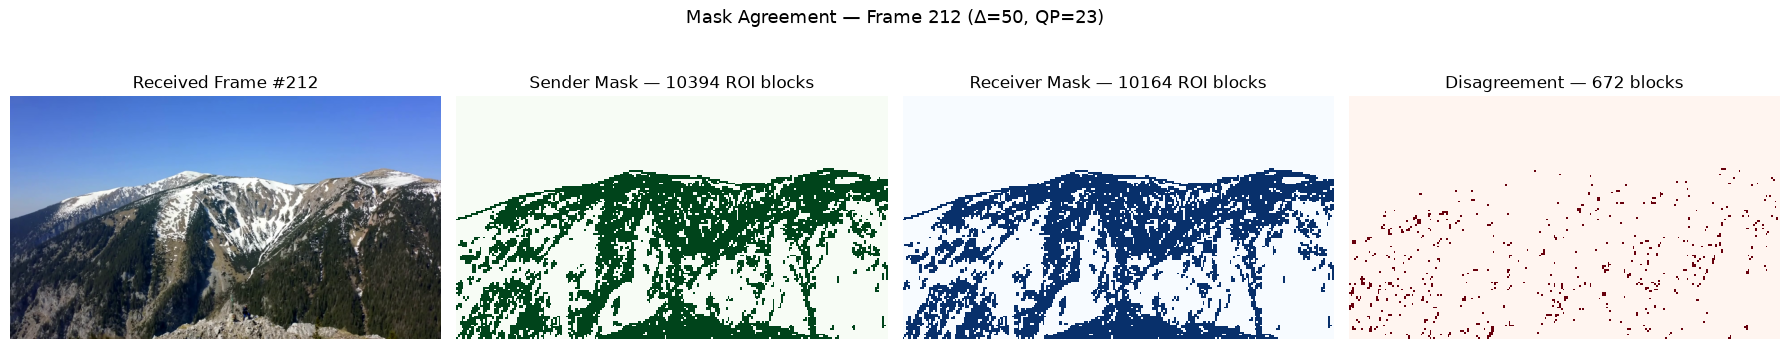

  Saved figure -> 'mask_agreement.png'


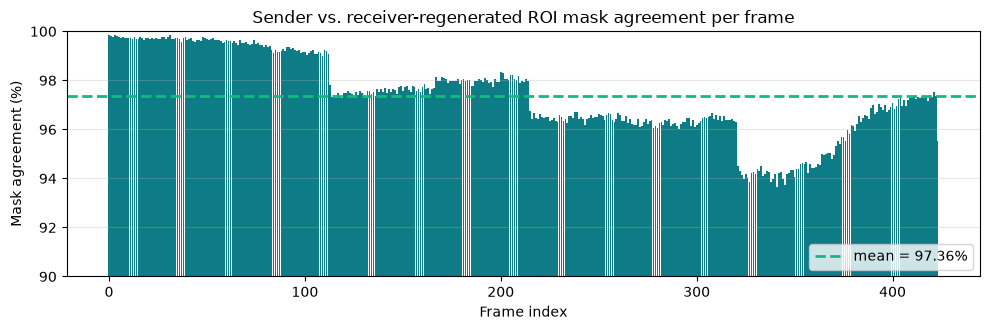

  Saved figure -> 'mask_agreement_perframe.png'


In [15]:
# ── Plot 1: Mask agreement heatmap on a representative frame ─────────
if os.path.exists(ROI_MASKS_FILE_M3) and len(received_frames) > 0:
    sample_idx = len(received_frames) // 2  # middle frame
    
    sender_mask    = sender_masks[sample_idx]
    receiver_mask  = regenerated_masks[sample_idx]
    
    # Disagreement: 1 where masks differ, 0 where they match
    disagreement = (sender_mask != receiver_mask).astype(np.uint8)
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    
    axes[0].imshow(cv2.cvtColor(received_frames[sample_idx], cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Received Frame #{sample_idx}")
    axes[0].axis('off')
    
    axes[1].imshow(sender_mask, cmap='Greens', interpolation='nearest')
    axes[1].set_title(f"Sender Mask — {int(np.sum(sender_mask))} ROI blocks")
    axes[1].axis('off')
    
    axes[2].imshow(receiver_mask, cmap='Blues', interpolation='nearest')
    axes[2].set_title(f"Receiver Mask — {int(np.sum(receiver_mask))} ROI blocks")
    axes[2].axis('off')
    
    axes[3].imshow(disagreement, cmap='Reds', interpolation='nearest')
    axes[3].set_title(f"Disagreement — {int(np.sum(disagreement))} blocks")
    axes[3].axis('off')
    
    plt.suptitle(f"Mask Agreement — Frame {sample_idx} "
                 f"(Δ={QIM_DELTA}, QP={embedding_meta.get('qp', '?')})",
                 fontsize=13)
    plt.tight_layout()
    plt.savefig('mask_agreement.png', dpi=150, bbox_inches='tight')   # for the slide
    plt.show()
    print("  Saved figure -> 'mask_agreement.png'")

    # ── Plot 2: per-frame agreement across the whole clip (slide figure) ──
    fig2, ax2 = plt.subplots(figsize=(10, 3.4))
    frames_axis = np.arange(len(agreement_pct))
    ax2.bar(frames_axis, agreement_pct, color='#0E7C86', width=0.9)
    ax2.axhline(np.mean(agreement_pct), color='#13B981', ls='--', lw=2,
                label=f"mean = {np.mean(agreement_pct):.2f}%")
    ax2.set_ylim(min(90, np.min(agreement_pct) - 2), 100)
    ax2.set_xlabel("Frame index")
    ax2.set_ylabel("Mask agreement (%)")
    ax2.set_title("Sender vs. receiver-regenerated ROI mask agreement per frame")
    ax2.legend(loc='lower right')
    ax2.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('mask_agreement_perframe.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  Saved figure -> 'mask_agreement_perframe.png'")
else:
    print("  (Sender masks unavailable — skipping mask agreement plot)")

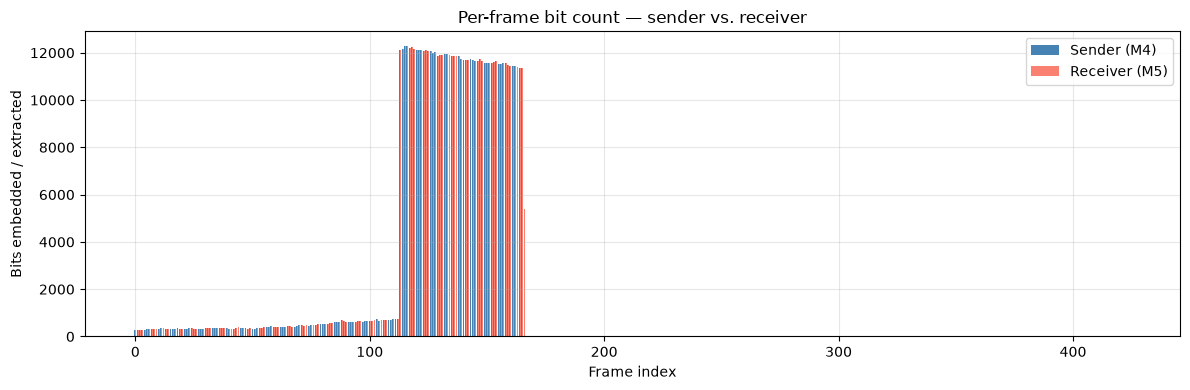

In [16]:
# ── Plot 2: Per-frame bit count — sender vs. receiver ────────────────
embedded_per_frame  = BITS_PER_FRAME
extracted_per_frame = [
    log['bits'] for log in extraction_log
] + [0] * (TOTAL_FRAMES - len(extraction_log))

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(min(len(embedded_per_frame), len(extracted_per_frame)))
ax.bar(x - 0.2, embedded_per_frame[:len(x)], width=0.4,
       label='Sender (M4)', color='steelblue')
ax.bar(x + 0.2, extracted_per_frame[:len(x)], width=0.4,
       label='Receiver (M5)', color='salmon')
ax.set_xlabel("Frame index")
ax.set_ylabel("Bits embedded / extracted")
ax.set_title("Per-frame bit count — sender vs. receiver")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 13: Save the Extraction Report

We persist the extraction diagnostics into `extraction_report.npy` so
they can be loaded by Module 7 (Quality Benchmarking) when populating
the thesis results tables.

In [17]:
extraction_report = {
    # Inputs used
    'stego_video':           STEGO_VIDEO_PATH,
    'metadata_file':         EMBED_META_FILE,
    
    # Parameters (loaded from metadata, mirrored for the report)
    'block_size':            BLOCK_SIZE,
    'coeff_pos':             COEFF_POS,
    'qim_delta':             QIM_DELTA,
    'qp':                    embedding_meta.get('qp', None),
    
    # Extraction results
    'frames_processed':      len(received_frames),
    'bits_extracted':        len(extracted_bits_array),
    'bytes_extracted':       len(extracted_bytes),
    'expected_bits':         PAYLOAD_BITS,
    'expected_bytes':        PAYLOAD_BYTES,
    
    # Diagnostics (None if reference not available)
    'ber':                   ber,
    'bit_errors':            errors,
    'perfect_byte_match':    (
        extracted_bytes == open(ORIGINAL_CIPHERTEXT, 'rb').read()
        if os.path.exists(ORIGINAL_CIPHERTEXT) else None
    ),
    
    # Mask diagnostics
    'mask_agreement_pct':    (
        float(np.sum(sender_masks[:len(regenerated_masks)] == regenerated_masks)
              / regenerated_masks.size * 100)
        if os.path.exists(ROI_MASKS_FILE_M3) else None
    ),
    'mask_agreement_per_frame': (
        agreement_pct.tolist() if os.path.exists(ROI_MASKS_FILE_M3) else None
    ),
    'mask_agreement_mean':   (
        float(np.mean(agreement_pct)) if os.path.exists(ROI_MASKS_FILE_M3) else None
    ),
    'mask_agreement_min':    (
        float(np.min(agreement_pct)) if os.path.exists(ROI_MASKS_FILE_M3) else None
    ),
    
    # Per-frame extraction log
    'extraction_log':        extraction_log,
}

np.save(EXTRACTION_REPORT, extraction_report)
print(f"Extraction report saved to '{EXTRACTION_REPORT}'")
print()
for k, v in extraction_report.items():
    if k in ('extraction_log', 'mask_agreement_per_frame') and isinstance(v, list):
        print(f"  {k:24s}: ({len(v)} entries)")
    else:
        print(f"  {k:24s}: {v}")

Extraction report saved to 'extraction_report.npy'

  stego_video             : stego_compressed.mp4
  metadata_file           : embedding_metadata.npy
  block_size              : 8
  coeff_pos               : (2, 2)
  qim_delta               : 50
  qp                      : 23
  frames_processed        : 424
  bits_extracted          : 681360
  bytes_extracted         : 85170
  expected_bits           : 681360
  expected_bytes          : 85170
  ber                     : 0.17861336151226956
  bit_errors              : 1217
  perfect_byte_match      : False
  mask_agreement_pct      : 97.35870894479385
  mask_agreement_per_frame: (424 entries)
  mask_agreement_mean     : 97.35870894479385
  mask_agreement_min      : 93.66975308641975
  extraction_log          : (167 entries)


## Section 14: Summary

### Module 5 — DCT-QIM Extraction (Receiver Side) — Complete

This module recovers the encrypted ciphertext from a compressed stego
video using only public information (the video itself + the embedding
parameters). It demonstrates the **compression-resilience** novelty
of the QVSC thesis end-to-end.

| Item                        | Value |
|-----------------------------|-------|
| Color space                 | YCrCb |
| Channel decoded             | Y (luminance) |
| Transform                   | 2D DCT (Type II, orthonormal) |
| Block size                  | 8×8 |
| Coefficient position        | (2, 2) — low-frequency |
| QIM delta (Δ)               | 50 |
| ROI mask source             | Sender's masks (transmitted; non-blind) |
| Error correction            | Reed-Solomon (decoded in Module 6) |
| Compression survived        | H.264 / MP4 (constant QP) |

### Pipeline so far

```
[M1] E91 QKD → 256-bit key                        ✓ DONE
[M2] ChaCha20-Poly1305 encryption                 ✓ DONE
[FEC] Reed-Solomon + interleaving wrap            ✓ DONE
[M3] Canny ROI detection                          ✓ DONE
[M4] DCT-QIM embedding (Y, informed) + QP H.264   ✓ DONE
[M5] DCT-QIM extraction (sender masks, non-blind) ✓ DONE  ← (this notebook)
[M6] FEC decode → ChaCha20-Poly1305 verify        ⏳ NEXT
[M7] PSNR / SSIM / BER benchmarking + figures     ⏳ PENDING
```

### What feeds into Module 6

`extracted_ciphertext.bin` — same byte-level structure as Module 2's
`ciphertext.bin`:

```
[ Nonce (12B) ][ Ciphertext (variable) ][ Poly1305 tag (16B) ]
```

Module 6 will:
1. Read this file plus `quantum_key.bin` from Module 1
2. Verify the Poly1305 tag (the AEAD integrity guarantee)
3. Decrypt with ChaCha20 → recover the original plaintext

If even one bit was flipped during transmission/extraction, the tag
check fails and Module 6 rejects the message — which is exactly the
security guarantee we want.

### Key takeaway for the thesis

Module 5 is what makes the QVSC framework practically useful: it
proves that ciphertext can survive lossy video compression while
remaining recoverable from public information alone, with no shared
state between sender and receiver beyond the publicly-agreed
embedding parameters.